# Aperiodic boundary conditions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import matplotlib.animation as animation
from IPython.display import HTML

## Defining and plotting the envelope

In [2]:
M = 50
s0 = np.random.uniform(0,0.1, (4, M))
tau = 10e-3
B0 = 1
alpha = 0.1

In [3]:
A_exc = 1
A_inh = 1
sigma_exc = 4.8
sigma_inh = 5

def mexican_hat_2d(xv, yv, A_exc, sigma_exc, A_inh, sigma_inh):
    return A_exc*np.e**(-(xv**2+yv**2)/sigma_exc**2) - A_inh*np.e**(-(xv**2+yv**2)/sigma_inh**2)

In [4]:
gamma = 0.08
f_ratio = 0.2
M = 50

def e_calc(xv, yv):
    R_fade = f_ratio*M/2
    return np.exp(-gamma**2*np.maximum(0, xv**2+yv**2 - R_fade))

In [5]:
nx, ny = (M, M)
x = np.arange(-M/2, M/2, 1)
y = np.arange(-M/2, M/2, 1)
xv, yv = np.meshgrid(x, y)

w = mexican_hat_2d(xv, yv, A_exc, sigma_exc, A_inh, sigma_inh)
e = e_calc(xv, yv)

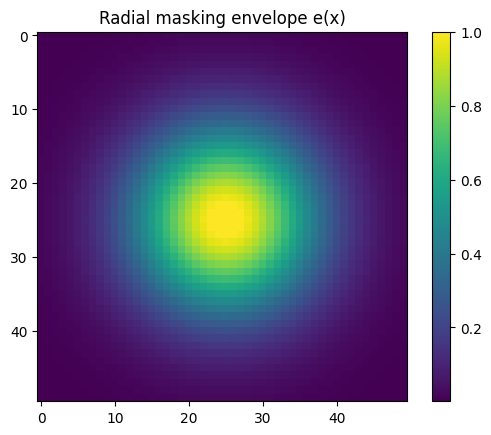

In [6]:
plt.imshow(e)
plt.colorbar()
plt.title("Radial masking envelope e(x)")
plt.show()

In [7]:
wE = np.zeros((M, M))
wW = np.zeros((M, M))
wN = np.zeros((M, M))
wS = np.zeros((M, M))
l = 1

wE[:, l:] = w[:, :-l]
wE[:, :l] = w[:, -l:]

wW[:, :-l] = w[:, l:]
wW[:, -l:] = w[:, :l]

wS[l:, :] = w[:-l, :]
wS[:l, :] = w[-l:, :]

wN[:-l, :] = w[l:, :]
wN[-l:, :] = w[:l, :]

wD = np.zeros((4, M, M))
wD[0] = wN
wD[1] = wS
wD[2] = wE
wD[3] = wW

## A first aperiodic solution

In [29]:
v_y = 0
v_x = 0

def ds_aperiodic(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y),
    B0 * (1 - alpha*v_y),
    B0 * (1 + alpha*v_x),
    B0 * (1 - alpha*v_x),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='constant')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds


In [30]:
def forward_euler(ds, tSpan, dt, s0, rec):

    t = np.arange(tSpan[0], tSpan[1], dt)
    s = np.zeros((4, M, M))
    s = s0
    tstamps = []
    
    for i in range(1, len(t)):

        s = s + dt * ds(s, t[i-1])

        if i % rec == 0:

            tstamps.append(np.sum(np.maximum(0, s), axis=0)) # Saving sums of firing rates at time stamps

    return np.array(tstamps)

In [32]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_aperiodic = forward_euler(ds_aperiodic, [0, 200e-3], 1e-3, s0, 10)

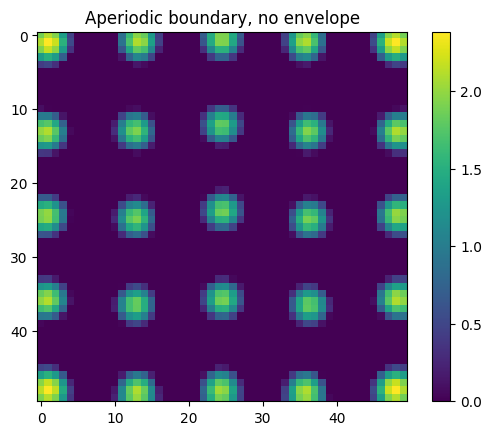

In [33]:
plt.imshow(sol_aperiodic[-1])
plt.title("Aperiodic boundary, no envelope")
plt.colorbar()
plt.show()

In [35]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_aperiodic)):

    im = ax.imshow(sol_aperiodic[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_aperiodic[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of grid formation, aperiodic conditions")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

### Adding the envelope to the firing rate during convolution

In [36]:
v_x = 0
v_y = 0

def ds_aperiodic_rscaled(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y),
    B0 * (1 - alpha*v_y),
    B0 * (1 + alpha*v_x),
    B0 * (1 - alpha*v_x),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop]*e, wD[pop], mode='constant')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds

In [37]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_rscaled = forward_euler(ds_aperiodic_rscaled, [0, 200e-3], 1e-3, s0, 10)

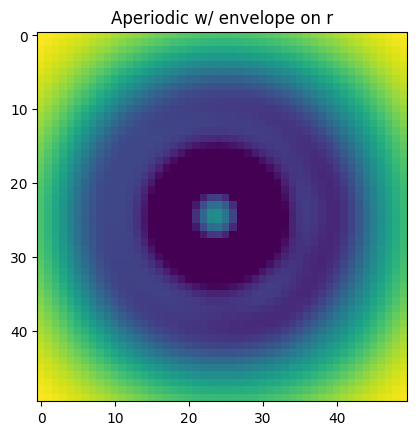

In [38]:
plt.imshow(sol_rscaled[-1])
plt.title("Aperiodic w/ envelope on r")
plt.show()

In [40]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_rscaled)):

    im = ax.imshow(sol_rscaled[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_rscaled[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation, adding the envelope during convolution")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

#### Adding the envelope to B instead

In [41]:
v_x = 0
v_y = 0

def ds_aperiodic_Bscaled(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y),
    B0 * (1 - alpha*v_y),
    B0 * (1 + alpha*v_x),
    B0 * (1 - alpha*v_x),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='constant')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop]*e)
    
    return ds

In [42]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_Bscaled = forward_euler(ds_aperiodic_Bscaled, [0, 200e-3], 1e-3, s0, 10)

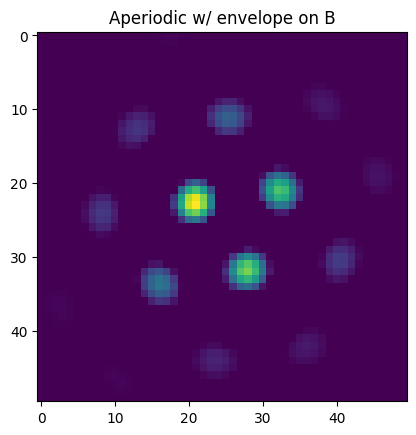

In [43]:
plt.imshow(sol_Bscaled[-1])
plt.title("Aperiodic w/ envelope on B")
plt.show()

In [44]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_Bscaled)):

    im = ax.imshow(sol_Bscaled[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_Bscaled[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of grid formation")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

### Random velocity input and bump velocity

In [47]:
speeds = np.random.uniform(1,2, size=11)
speeds[0] = 0
thetas = np.random.uniform(0, 2*np.pi, size=11)
vs = np.zeros((11, 2))
for i in range(11):
    vs[i,0] = speeds[i]*np.cos(thetas[i])
    vs[i,1] = speeds[i]*np.sin(thetas[i])

v_x = vs[:,0]
v_y = vs[:,1]

def ds_Bscaled_randV(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y[int(t//100e-3)]),
    B0 * (1 - alpha*v_y[int(t//100e-3)]),
    B0 * (1 + alpha*v_x[int(t//100e-3)]),
    B0 * (1 - alpha*v_x[int(t//100e-3)]),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='constant')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop]*e)
    
    return ds

In [48]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_Bscaled_randV = forward_euler(ds_Bscaled_randV, [0, 1100e-3], 1e-3, s0, 10)

In [49]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_Bscaled_randV)):

    im = ax.imshow(sol_Bscaled_randV[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_Bscaled_randV[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=500, blit=True,
                                repeat_delay=1000)

plt.title("Animation of 10 random velocities")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

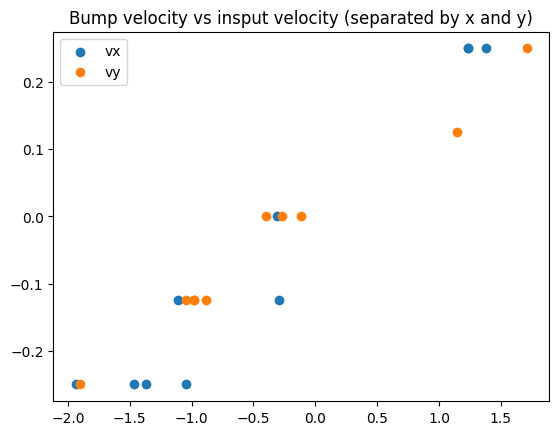

In [50]:

bVel_x = np.zeros(11)
bVel_y = np.zeros(11)


for i in range(0, 109, 10):

    k0 = np.array(np.unravel_index(np.argmax(sol_Bscaled_randV[i, 10:30, 10:30], axis=None), sol_Bscaled_randV[i, 10:30, 10:30].shape)) + [10, 10]
    ks = [k0]
    for j in range(1, 9):
        k0 = np.array(np.unravel_index(np.argmax(sol_Bscaled_randV[i+j, k0[0]-5 : k0[0]+5, k0[1]-5 : k0[1]+5], axis=None), sol_Bscaled_randV[i+j, k0[0]-5 : k0[0]+5, k0[1]-5 : k0[1]+5].shape))+ np.array([k0[0]-5, k0[1]-5])
        ks.append(k0) 
    
    
    ks = np.array(ks)

    bVel_x[i//10] = np.mean(ks[1:, 1]-ks[:-1, 1])
    bVel_y[i//10] = -np.mean(ks[1:, 0]-ks[:-1, 0])


# What should the units be here? Do we divide by 300e-3? or by 300?
plt.title('Bump velocity vs insput velocity (separated by x and y)')
plt.scatter(vs[1:, 0], bVel_x[1:], label='vx')
plt.scatter(vs[1:, 1], bVel_y[1:], label = 'vy')
plt.legend()
plt.show()
